# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_bpb, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["val_bpb"] = pd.to_numeric(df["val_bpb"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 102
Columns: ['commit', 'val_bpb', 'memory_gb', 'status', 'description']


,commit,val_bpb,memory_gb,status,description
0,a43a3e7,1.624905,4.2,KEEP,"baseline (Jetson Orin Nano Super, no torch.com..."
1,e3aab3d,1.568024,3.7,KEEP,DEPTH=6
2,d1a7ead,1.543826,2.6,KEEP,DEPTH=4 (+ fixed pyproject.toml for Jetson)
3,84c9e1f,1.545397,2.5,DISCARD,DEPTH=3
4,5a8f565,1.602286,2.6,DISCARD,TOTAL_BATCH_SIZE=2^15
5,3225f9f,1.534246,1.3,KEEP,TOTAL_BATCH_SIZE=2^13 DEVICE_BATCH_SIZE=16
6,90d7ea3,1.540057,0.7,DISCARD,TOTAL_BATCH_SIZE=2^12 DEVICE_BATCH_SIZE=8
7,42521b2,1.522878,1.3,KEEP,WARMDOWN_RATIO=0.7
8,e5917d4,1.529259,1.3,DISCARD,WARMDOWN_RATIO=0.5
9,08b9bd3,1.531435,1.3,DISCARD,WARMDOWN_RATIO=0.75


In [2]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    60
KEEP       41
CRASH       1

Keep rate: 41/101 = 40.6%


In [3]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    bpb = row["val_bpb"]
    desc = row["description"]
    print(f"  #{i:3d}  bpb={bpb:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")

KEPT experiments (41 total):

  #  0  bpb=1.624905  mem=4.2GB  baseline (Jetson Orin Nano Super, no torch.compile, DEPTH=8)
  #  1  bpb=1.568024  mem=3.7GB  DEPTH=6
  #  2  bpb=1.543826  mem=2.6GB  DEPTH=4 (+ fixed pyproject.toml for Jetson)
  #  5  bpb=1.534246  mem=1.3GB  TOTAL_BATCH_SIZE=2^13 DEVICE_BATCH_SIZE=16
  #  7  bpb=1.522878  mem=1.3GB  WARMDOWN_RATIO=0.7
  # 10  bpb=1.521740  mem=1.3GB  MATRIX_LR=0.03
  # 11  bpb=1.519965  mem=1.3GB  MATRIX_LR=0.04
  # 14  bpb=1.519722  mem=1.3GB  EMBEDDING_LR=2.0
  # 15  bpb=1.514597  mem=1.3GB  EMBEDDING_LR=1.5
  # 16  bpb=1.506383  mem=1.3GB  EMBEDDING_LR=1.0
  # 18  bpb=1.503142  mem=1.3GB  WEIGHT_DECAY=0.1
  # 21  bpb=1.495860  mem=1.6GB  ASPECT_RATIO=64 (model_dim=256)
  # 22  bpb=1.495167  mem=2.0GB  ASPECT_RATIO=96 (model_dim=384)
  # 31  bpb=1.486708  mem=1.8GB  GeLU activation
  # 32  bpb=1.486253  mem=1.9GB  SiLU activation
  # 34  bpb=1.481041  mem=1.6GB  remove softcap on logits
  # 35  bpb=1.461496  mem=1.6GB  MATRIX_LR=0.05 

## Val BPB Over Time

Track how the best (kept) val_bpb evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

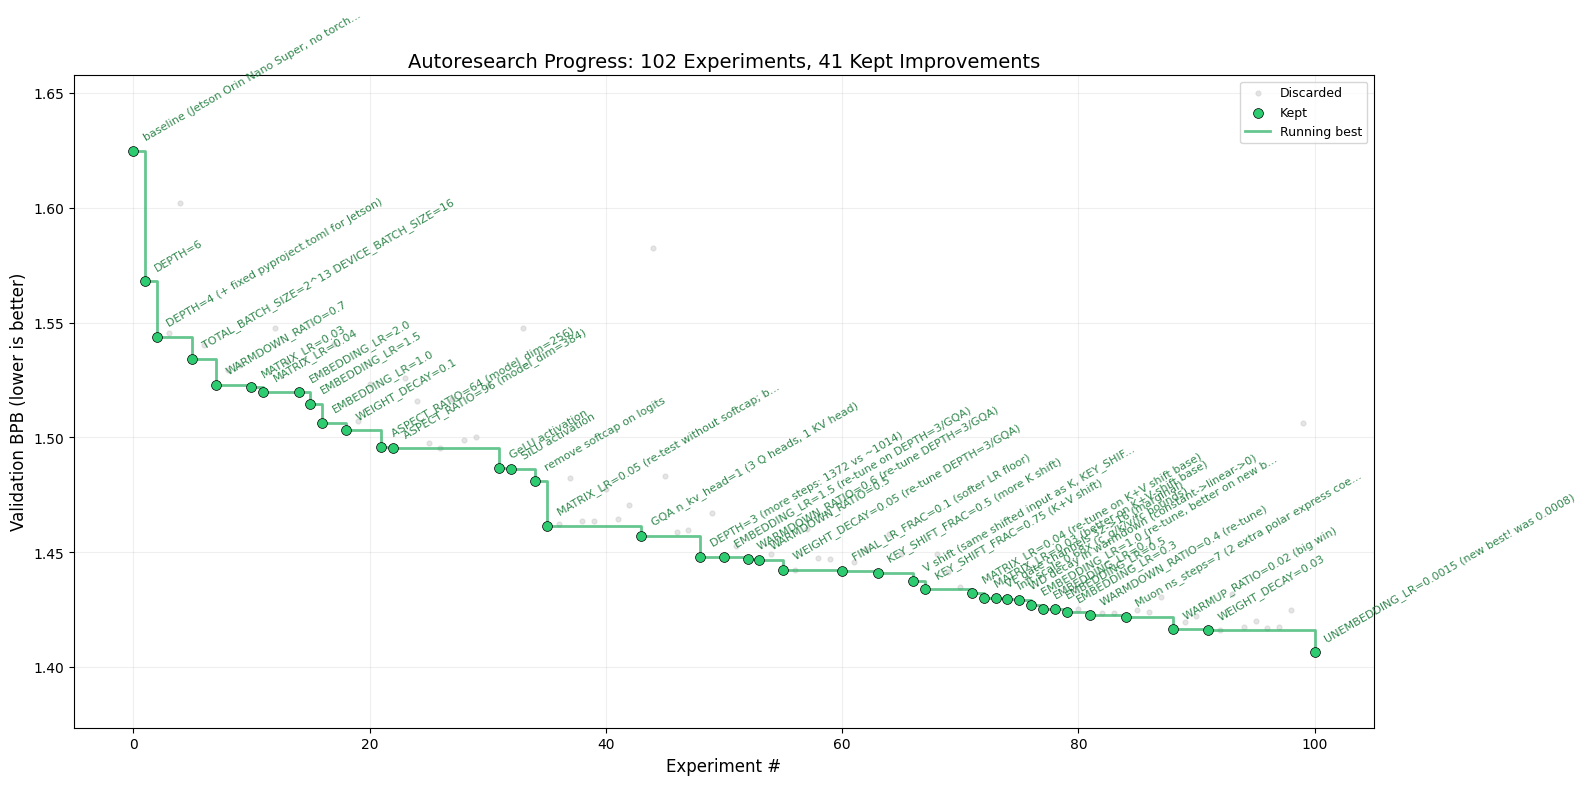

Saved to progress.png


In [4]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_bpb = valid.loc[0, "val_bpb"]

# Only plot points at or below baseline (the interesting region)
below = valid[valid["val_bpb"] <= baseline_bpb + 0.0005]

# Plot discarded as faint background dots
disc = below[below["status"] == "DISCARD"]
ax.scatter(disc.index, disc["val_bpb"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = below[below["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["val_bpb"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running minimum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_bpb = valid.loc[kept_mask, "val_bpb"]
running_min = kept_bpb.cummin()
ax.step(kept_idx, running_min, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, bpb in zip(kept_idx, kept_bpb):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, bpb),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation BPB (lower is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below best to just above baseline
best_bpb = kept_bpb.min()
margin = (baseline_bpb - best_bpb) * 0.15
ax.set_ylim(best_bpb - margin, baseline_bpb + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [5]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_bpb = df.iloc[0]["val_bpb"]
best_bpb = kept["val_bpb"].min()
best_row = kept.loc[kept["val_bpb"].idxmin()]

print(f"Baseline val_bpb:  {baseline_bpb:.6f}")
print(f"Best val_bpb:      {best_bpb:.6f}")
print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpb={row['val_bpb']:.6f}  {desc}")

Baseline val_bpb:  1.624905
Best val_bpb:      1.406354
Total improvement: 0.218551 (13.45%)
Best experiment:   UNEMBEDDING_LR=0.0015 (new best! was 0.0008)

Cumulative effort per improvement:
  Experiment #  0: bpb=1.624905  baseline (Jetson Orin Nano Super, no torch.compile, DEPTH=8)
  Experiment #  1: bpb=1.568024  DEPTH=6
  Experiment #  2: bpb=1.543826  DEPTH=4 (+ fixed pyproject.toml for Jetson)
  Experiment #  5: bpb=1.534246  TOTAL_BATCH_SIZE=2^13 DEVICE_BATCH_SIZE=16
  Experiment #  7: bpb=1.522878  WARMDOWN_RATIO=0.7
  Experiment # 10: bpb=1.521740  MATRIX_LR=0.03
  Experiment # 11: bpb=1.519965  MATRIX_LR=0.04
  Experiment # 14: bpb=1.519722  EMBEDDING_LR=2.0
  Experiment # 15: bpb=1.514597  EMBEDDING_LR=1.5
  Experiment # 16: bpb=1.506383  EMBEDDING_LR=1.0
  Experiment # 18: bpb=1.503142  WEIGHT_DECAY=0.1
  Experiment # 21: bpb=1.495860  ASPECT_RATIO=64 (model_dim=256)
  Experiment # 22: bpb=1.495167  ASPECT_RATIO=96 (model_dim=384)
  Experiment # 31: bpb=1.486708  GeLU act

## Top Hits (Kept Experiments by Improvement)

In [6]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpb
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["val_bpb"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["val_bpb"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPB':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['val_bpb']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")

Rank     Delta         BPB  Description
--------------------------------------------------------------------------------
   1  +0.056881  1.568024  DEPTH=6
   2  +0.024198  1.543826  DEPTH=4 (+ fixed pyproject.toml for Jetson)
   3  +0.019545  1.461496  MATRIX_LR=0.05 (re-test without softcap; big win)
   4  +0.011368  1.522878  WARMDOWN_RATIO=0.7
   5  +0.009649  1.406354  UNEMBEDDING_LR=0.0015 (new best! was 0.0008)
   6  +0.009580  1.534246  TOTAL_BATCH_SIZE=2^13 DEVICE_BATCH_SIZE=16
   7  +0.009110  1.448032  DEPTH=3 (more steps: 1372 vs ~1014)
   8  +0.008459  1.486708  GeLU activation
   9  +0.008214  1.506383  EMBEDDING_LR=1.0
  10  +0.007282  1.495860  ASPECT_RATIO=64 (model_dim=256)
  11  +0.005262  1.416517  WARMUP_RATIO=0.02 (big win)
  12  +0.005212  1.481041  remove softcap on logits
  13  +0.005125  1.514597  EMBEDDING_LR=1.5
  14  +0.004435  1.442340  WEIGHT_DECAY=0.05 (re-tune DEPTH=3/GQA)
  15  +0.004354  1.457142  GQA n_kv_head=1 (3 Q heads, 1 KV head)
  16  +0.003620